In [1]:
# Cell 0 — Config & Utils

import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [2]:
# Cell 1 — DB Connection

load_dotenv()

PGUSER=os.getenv("PGUSER")
PGHOST=os.getenv("PGHOST")
PGDATABASE=os.getenv("PGDATABASE")
PGPASSWORD=os.getenv("PGPASSWORD")
PGPORT=os.getenv("PGPORT")


engine = create_engine(f"postgresql+psycopg2://{PGUSER}:{PGPASSWORD}@{PGHOST}:{PGPORT}/{PGDATABASE}")

def q(sql: str) -> pd.DataFrame:
    """Safe SQL runner compatible with SQLAlchemy 2.x."""
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn)

def show(df, n=5):
    display(df.head(n))

def exec_sql(sql: str):
    """Execute DDL/DML SQL (no resultset)."""
    with engine.begin() as conn:
        conn.execute(text(sql))

In [3]:
# Cell 2 — Global constants

SCHEMA       = "public"
RAW_TABLE    = "fm_2024_union_typed"    # Fannie Mae 2024 typed panel
SEQ_L        = 12                       # Sequence length for RNN (months)
SEED         = 42

# Default threshold (90+ DPD = delinquency status >= 3)
DEFAULT_DQ_THRESHOLD = 3

# Ensure output directory exists
os.makedirs("outputs", exist_ok=True)

print(f"Config: SEQ_L={SEQ_L}, DEFAULT_DQ_THRESHOLD={DEFAULT_DQ_THRESHOLD}, SEED={SEED}")


Config: SEQ_L=12, DEFAULT_DQ_THRESHOLD=3, SEED=42


---
# ═══════════════════════════════════════════
# BLOCK 1 — DESCRIPTIVE ANALYTICS (APPENDIX)
# ═══════════════════════════════════════════

Purpose: produce summary tables & figures for the **Appendix** of the article.
- A1. Dataset overview (panel dimensions)
- A2. Per-column profiling (type, fill rate, basic stats)
- A3. Target variable (delinquency & default distribution)
- A4. Key origination features distributions

In [9]:
# 1.0 — Column inventory of raw table

col_meta = q(f"""
SELECT column_name, data_type, ordinal_position
FROM information_schema.columns
WHERE table_schema = '{SCHEMA}'
  AND table_name   = '{RAW_TABLE}'
ORDER BY ordinal_position;
""")

assert not col_meta.empty, f"Table {SCHEMA}.{RAW_TABLE} not found!"

# normalised helpers
col_meta["col"] = col_meta["column_name"].str.strip()
all_columns = col_meta["col"].tolist()
col_types   = dict(zip(col_meta["col"], col_meta["data_type"]))

print(f"Table {SCHEMA}.{RAW_TABLE}: {len(col_meta)} columns")
display(col_meta[["ordinal_position","col","data_type"]])

Table public.fm_2024_union_typed: 110 columns


,ordinal_position,col,data_type
0,1,reference_pool_id,character varying
1,2,loan_identifier,character varying
2,3,monthly_reporting_period,date
3,4,channel,character varying
4,5,seller_name,character varying
...,...,...,...
105,106,alternative_delinquency_resolution,character varying
106,107,alternative_delinquency_resolution_count,integer
107,108,total_deferral_amount,numeric
108,109,payment_deferral_modification_event_indicator,character varying


In [10]:
# 1.1 — A1: Dataset overview (panel dimensions)

# Flexible column resolution
def pick(candidates):
    for c in candidates:
        if c.lower() in [x.lower() for x in all_columns]:
            return next(x for x in all_columns if x.lower()==c.lower())
    return None

loan_col  = pick(["loan_identifier","loan_id"])
mpr_col   = pick(["monthly_reporting_period","month","as_of_month"])
dq_col    = pick(["current_loan_delinquency_status","dq_m","delinquency_status"])
upb_col   = pick(["current_actual_upb","upb","current_upb"])
rate_col  = pick(["current_interest_rate","rate"])
ltv_col   = pick(["original_loan_to_value_ratio_ltv","original_ltv","ltv"])
cltv_col  = pick(["original_combined_loan_to_value_ratio_cltv","cltv"])
dti_col   = pick(["debt_to_income_dti","dti","debt_to_income", "debttoincome_dti"])
fico_col  = pick(["borrower_credit_score_at_origination","fico","credit_score"])
orig_upb  = pick(["original_upb","orig_upb"])
term_col  = pick(["original_loan_term","loan_term"])
chan_col  = pick(["channel"])
state_col = pick(["property_state"])
zb_col    = pick(["zero_balance_code"])
occ_col   = pick(["occupancy_status"])
prop_col  = pick(["property_type"])
purp_col  = pick(["loan_purpose"])
mi_col    = pick(["mortgage_insurance_percentage"])
nbor_col  = pick(["number_of_borrowers"])
age_col   = pick(["loan_age"])
sch_prin  = pick(["scheduled_principal_current","sch_prin"])
tot_prin  = pick(["total_principal_current","tot_prin"])
unsch_prin= pick(["unscheduled_principal_current","unsch_prin"])
mod_col   = pick(["modification_flag"])
defer_col = pick(["total_deferral_amount"])
delin_int = pick(["delinquent_accrued_interest"])
bap_col   = pick(["borrower_assistance_plan"])
adr_col   = pick(["alternative_delinquency_resolution"])
fico_cur  = pick(["borrower_credit_score_current","current_classic_fico"])
lph_col   = pick(["loan_payment_history"])

print("Key columns resolved:")
for name, val in [
    ("loan_id",loan_col),("month",mpr_col),("delinquency",dq_col),
    ("UPB",upb_col),("rate",rate_col),("LTV",ltv_col),("CLTV",cltv_col),
    ("DTI",dti_col),("FICO",fico_col),("orig_UPB",orig_upb),
    ("term",term_col),("channel",chan_col),("state",state_col),
    ("zero_bal",zb_col),("sch_prin",sch_prin),("tot_prin",tot_prin),
    ("unsch_prin",unsch_prin),("mod_flag",mod_col),("deferral",defer_col),
    ("delin_interest",delin_int),("FICO_current",fico_cur),
]:
    status = "✓" if val else "✗ MISSING"
    print(f"  {name:20s} → {str(val):50s} {status}")

Key columns resolved:
  loan_id              → loan_identifier                                    ✓
  month                → monthly_reporting_period                           ✓
  delinquency          → current_loan_delinquency_status                    ✓
  UPB                  → current_actual_upb                                 ✓
  rate                 → current_interest_rate                              ✓
  LTV                  → original_loan_to_value_ratio_ltv                   ✓
  CLTV                 → original_combined_loan_to_value_ratio_cltv         ✓
  DTI                  → debttoincome_dti                                   ✓
  FICO                 → borrower_credit_score_at_origination               ✓
  orig_UPB             → original_upb                                       ✓
  term                 → original_loan_term                                 ✓
  channel              → channel                                            ✓
  state                → property_state   

In [11]:
# 1.2 — Panel summary: N loans, N loan-months, temporal range, avg history length

assert loan_col and mpr_col, "loan_id and month columns must be resolved"

# Month expression
mpr_type = col_types.get(mpr_col, "").lower()
if "date" in mpr_type or "timestamp" in mpr_type:
    month_expr = f"date_trunc('month', \"{mpr_col}\")::date"
else:
    month_expr = f"""CASE
      WHEN regexp_replace(\"{mpr_col}\"::text, '\\D', '', 'g') ~ '^\\d{{5,6}}$'
        THEN to_date(lpad(regexp_replace(\"{mpr_col}\"::text, '\\D', '', 'g'), 6, '0'), 'MMYYYY')
      ELSE (\"{mpr_col}\"::date) END"""

# DQ int expression
if dq_col:
    dq_type = col_types.get(dq_col, "").lower()
    if any(t in dq_type for t in ["int","numeric","double","real"]):
        dq_expr = f'\"{dq_col}\"::int'
    else:
        dq_expr = f"""CASE WHEN \"{dq_col}\"::text ~ '^\\s*\\d+\\s*$'
            THEN trim(\"{dq_col}\"::text)::int ELSE NULL END"""
else:
    dq_expr = "NULL::int"

overview = q(f"""
WITH base AS (
  SELECT
    \"{loan_col}\" AS lid,
    ({month_expr}) AS m
  FROM {SCHEMA}.\"{RAW_TABLE}\"
  WHERE \"{loan_col}\" IS NOT NULL
    AND \"{mpr_col}\" IS NOT NULL
)
SELECT
  COUNT(*)::bigint                        AS n_loan_months,
  COUNT(DISTINCT lid)::bigint             AS n_loans,
  MIN(m)                                  AS min_month,
  MAX(m)                                  AS max_month,
  (MAX(m) - MIN(m))                       AS date_span,
  ROUND(COUNT(*)::numeric / NULLIF(COUNT(DISTINCT lid),0), 1) AS avg_months_per_loan
FROM base;
""")
display(overview.T.rename(columns={0: 'Value'}))
overview.to_csv("outputs/A1_panel_overview.csv", index=False)

,Value
n_loan_months,14130111
n_loans,970976
min_month,2024-01-01
max_month,2025-09-01
date_span,609
avg_months_per_loan,14.6


In [6]:
# 1.3 — A2: Per-column profiling (fill rate, distinct count, min/max/mean for numerics)
#
# We compute everything in SQL to avoid loading the full table into RAM.

profile_parts = []
for c in all_columns:
    dt = col_types.get(c, "")
    # All columns: fill_rate, n_distinct
    # Numeric columns: min, max, mean, stddev
    is_num = any(t in dt.lower() for t in ["int","numeric","double","real","decimal","float"])
    if is_num:
        part = f"""SELECT
            '{c}' AS column_name,
            '{dt}' AS data_type,
            COUNT(*)::bigint AS n_total,
            SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::bigint AS n_filled,
            ROUND(SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::numeric / NULLIF(COUNT(*),0) * 100, 2) AS fill_pct,
            COUNT(DISTINCT \"{c}\")::bigint AS n_distinct,
            ROUND(MIN(\"{c}\"::numeric), 4) AS val_min,
            ROUND(MAX(\"{c}\"::numeric), 4) AS val_max,
            ROUND(AVG(\"{c}\"::numeric), 4) AS val_mean,
            ROUND(STDDEV(\"{c}\"::numeric), 4) AS val_std
        FROM {SCHEMA}.\"{RAW_TABLE}\""""
    else:
        part = f"""SELECT
            '{c}' AS column_name,
            '{dt}' AS data_type,
            COUNT(*)::bigint AS n_total,
            SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::bigint AS n_filled,
            ROUND(SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::numeric / NULLIF(COUNT(*),0) * 100, 2) AS fill_pct,
            COUNT(DISTINCT \"{c}\")::bigint AS n_distinct,
            NULL::numeric AS val_min,
            NULL::numeric AS val_max,
            NULL::numeric AS val_mean,
            NULL::numeric AS val_std
        FROM {SCHEMA}.\"{RAW_TABLE}\""""
    profile_parts.append(part)

# Run in batches to avoid SQL too long
batch_size = 15
profile_dfs = []
for i in range(0, len(profile_parts), batch_size):
    batch = profile_parts[i:i+batch_size]
    sql = " UNION ALL ".join(batch)
    profile_dfs.append(q(sql))

profile = pd.concat(profile_dfs, ignore_index=True)
profile = profile.sort_values("fill_pct", ascending=True).reset_index(drop=True)

print(f"Column profiling: {len(profile)} columns")
display(profile)
profile.to_csv("outputs/A2_column_profile.csv", index=False)

Column profiling: 110 columns


,column_name,data_type,n_total,n_filled,fill_pct,n_distinct,val_min,val_max,val_mean,val_std
0,master_servicer,character varying,14130111,0,0.0,0,NaN,NaN,NaN,NaN
1,reference_pool_id,character varying,14130111,0,0.0,0,NaN,NaN,NaN,NaN
2,upb_at_issuance,numeric,14130111,0,0.0,0,NaN,NaN,NaN,NaN
3,asset_recovery_costs,numeric,14130111,30,0.0,4,0.0,2500.0,400.0,821.5838
4,credit_enhancement_proceeds,numeric,14130111,30,0.0,17,0.0,120285.63,28577.0937,36045.3544
...,...,...,...,...,...,...,...,...,...,...
105,high_loan_to_value_hltv_refinance_option_indic...,character varying,14130111,14130111,100.0,1,None,None,None,None
106,relocation_mortgage_indicator,character varying,14130111,14130111,100.0,2,NaN,NaN,NaN,NaN
107,special_eligibility_program,character varying,14130111,14130111,100.0,4,NaN,NaN,NaN,NaN
108,alternative_delinquency_resolution,character varying,14130111,14130111,100.0,4,NaN,NaN,NaN,NaN


=== Delinquency status distribution (loan-months) ===


,dq_m,n_obs,pct
0,0,14016151,99.1935
1,1,72610,0.5139
2,2,15892,0.1125
3,3,7610,0.0539
4,4,5021,0.0355
5,5,3741,0.0265
6,6,2607,0.0184
7,7,1869,0.0132
8,8,1428,0.0101
9,9,1019,0.0072



=== Loan-level default rate (ever 3+ DPD) ===


,n_loans,n_defaulted,default_rate_pct
0,970976,6145,0.6329


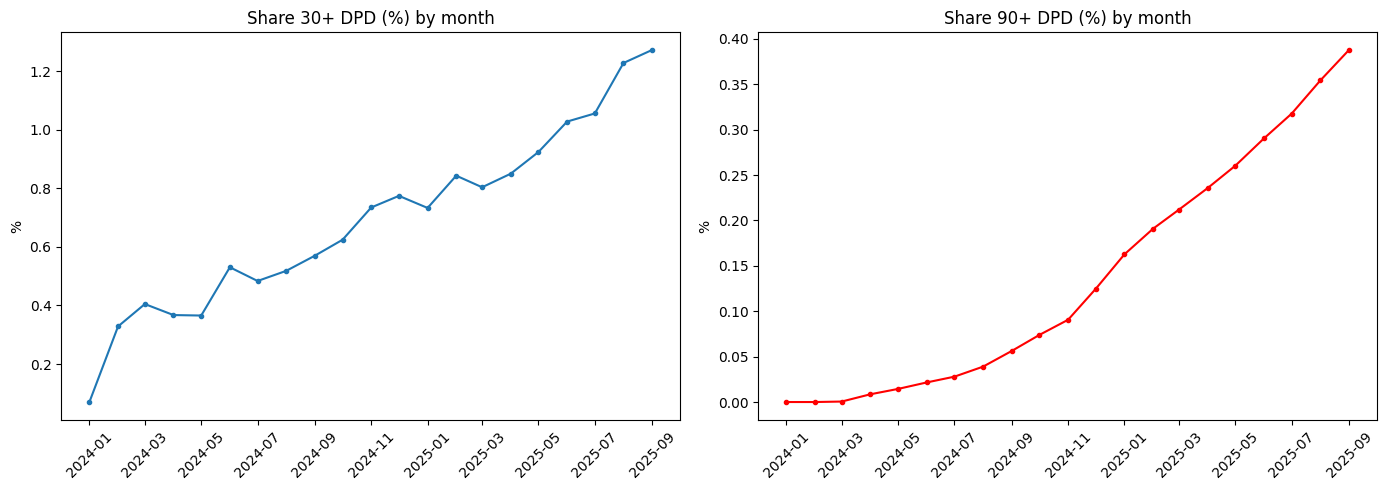

In [12]:
# 1.4 — A3: Delinquency & default distribution

if dq_col:
    # Distribution of delinquency status across loan-months
    dq_dist = q(f"""
    SELECT
      ({dq_expr}) AS dq_m,
      COUNT(*)    AS n_obs,
      ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 4) AS pct
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE ({dq_expr}) IS NOT NULL
    GROUP BY 1 ORDER BY 1;
    """)
    print("=== Delinquency status distribution (loan-months) ===")
    display(dq_dist)

    # Loan-level: ever reached 90+ DPD
    loan_default = q(f"""
    WITH loan_max_dq AS (
      SELECT \"{loan_col}\" AS lid,
             MAX(({dq_expr})) AS max_dq
      FROM {SCHEMA}.\"{RAW_TABLE}\"
      WHERE ({dq_expr}) IS NOT NULL
      GROUP BY 1
    )
    SELECT
      COUNT(*) AS n_loans,
      SUM(CASE WHEN max_dq >= {DEFAULT_DQ_THRESHOLD} THEN 1 ELSE 0 END) AS n_defaulted,
      ROUND(AVG(CASE WHEN max_dq >= {DEFAULT_DQ_THRESHOLD} THEN 1.0 ELSE 0.0 END) * 100, 4) AS default_rate_pct
    FROM loan_max_dq;
    """)
    print(f"\n=== Loan-level default rate (ever {DEFAULT_DQ_THRESHOLD}+ DPD) ===")
    display(loan_default)

    # Monthly delinquency rates (for time-series plot)
    dq_monthly = q(f"""
    SELECT
      ({month_expr}) AS month,
      AVG(CASE WHEN ({dq_expr}) >= 1 THEN 1.0 ELSE 0.0 END) AS share_30plus,
      AVG(CASE WHEN ({dq_expr}) >= 3 THEN 1.0 ELSE 0.0 END) AS share_90plus,
      COUNT(*) AS n_obs
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE ({month_expr}) IS NOT NULL AND ({dq_expr}) IS NOT NULL
    GROUP BY 1 ORDER BY 1;
    """)
    dq_monthly["month"] = pd.to_datetime(dq_monthly["month"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(dq_monthly["month"], dq_monthly["share_30plus"]*100, marker='o', markersize=3)
    axes[0].set_title("Share 30+ DPD (%) by month")
    axes[0].set_ylabel("%")
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(dq_monthly["month"], dq_monthly["share_90plus"]*100, marker='o', markersize=3, color='red')
    axes[1].set_title("Share 90+ DPD (%) by month")
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig("outputs/A3_delinquency_over_time.png", dpi=200)
    plt.show()

    dq_dist.to_csv("outputs/A3_dq_distribution.csv", index=False)
    loan_default.to_csv("outputs/A3_loan_default_rate.csv", index=False)
else:
    print("WARNING: delinquency column not found — skipping A3")

In [13]:
# 1.5 — A4: Distributions of key origination features

key_num_cols = {
    "LTV":          ltv_col,
    "CLTV":         cltv_col,
    "DTI":          dti_col,
    "FICO":         fico_col,
    "Orig_UPB":     orig_upb,
    "Loan_Term":    term_col,
    "Interest_Rate": rate_col,
    "Current_UPB":  upb_col,
}
key_num_cols = {k:v for k,v in key_num_cols.items() if v is not None}

key_cat_cols = {
    "Channel":     chan_col,
    "State":       state_col,
    "Occupancy":   occ_col,
    "Property":    prop_col,
    "Purpose":     purp_col,
}
key_cat_cols = {k:v for k,v in key_cat_cols.items() if v is not None}

# Numeric: percentiles via SQL
pctile_parts = []
for label, col in key_num_cols.items():
    pctile_parts.append(f"""
    SELECT '{label}' AS feature,
      COUNT(\"{col}\")::bigint AS n,
      ROUND(PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p01,
      ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p05,
      ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p25,
      ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS median,
      ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p75,
      ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p95,
      ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p99,
      ROUND(AVG(\"{col}\"::numeric), 2) AS mean,
      ROUND(STDDEV(\"{col}\"::numeric), 2) AS std
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE \"{col}\" IS NOT NULL
    """)

if pctile_parts:
    pctile_df = q(" UNION ALL ".join(pctile_parts))
    print("=== Key numeric features: percentile distribution ===")
    display(pctile_df)
    pctile_df.to_csv("outputs/A4_numeric_distributions.csv", index=False)

# Categorical: frequency tables (top values)
for label, col in key_cat_cols.items():
    cat_df = q(f"""
    SELECT \"{col}\"::text AS value,
           COUNT(*) AS n,
           ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 2) AS pct
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE \"{col}\" IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC LIMIT 15;
    """)
    print(f"\n--- {label} ({col}) ---")
    display(cat_df)

=== Key numeric features: percentile distribution ===


,feature,n,p01,p05,p25,median,p75,p95,p99,mean,std
0,Interest_Rate,14035150,4.99,5.63,6.38,6.63,7.13,7.63,8.13,6.70,0.63
1,Current_UPB,14130111,38282.46,85528.36,185089.49,283778.51,417000.00,681242.10,815000.00,318777.24,182164.99
2,DTI,14129837,13.00,20.00,31.00,39.00,45.00,49.00,50.00,37.37,9.24
3,Loan_Term,14130111,180.00,240.00,360.00,360.00,360.00,360.00,360.00,349.26,40.94
4,FICO,14106124,639.00,676.00,735.00,770.00,793.00,810.00,817.00,760.00,42.16
5,CLTV,14130111,19.00,33.00,64.00,80.00,90.00,97.00,101.00,74.96,19.85
6,LTV,14130111,19.00,33.00,64.00,80.00,90.00,97.00,97.00,74.64,19.69
7,Orig_UPB,14130111,60000.00,98000.00,194000.00,293000.00,428000.00,697000.00,831000.00,329389.74,183164.27



--- Channel (channel) ---


,value,n,pct
0,R,8417185,59.57
1,C,3802523,26.91
2,B,1910403,13.52



--- State (property_state) ---


...

,value,n,pct
0,P,12885357,91.19
1,I,983441,6.96
2,S,261313,1.85



--- Property (property_type) ---


,value,n,pct
0,SF,8183088,57.91
1,PU,4456879,31.54
2,CO,1243379,8.80
3,MH,180842,1.28
4,CP,65923,0.47



--- Purpose (loan_purpose) ---


,value,n,pct
0,P,11329721,80.18
1,C,1821846,12.89
2,R,978544,6.93


---
# ═════════════════════════════════════════
# BLOCK 2 — DATA QUALITY ASSESSMENT
# ═════════════════════════════════════════

Goal: classify **every column** into one of:
- **USE** — directly usable for modeling (fill rate ≥80%, sufficient variance)
- **DERIVE** — needs transformation / imputation / engineering, but contains signal
- **EXCLUDE** — too sparse, constant, post-event, or irrelevant

Criteria:
1. **Fill rate** < 5% → almost certainly EXCLUDE
2. **Fill rate** 5–80% → DERIVE (impute/flag) or EXCLUDE depending on relevance
3. **Near-constant** (n_distinct ≤ 2 on the whole panel, or std ≈ 0) → EXCLUDE
4. **Post-event** columns (foreclosure costs, disposition date, etc.) → EXCLUDE (survivorship / look-ahead bias)
5. **Identifier / admin** columns (seller_name, servicer_name, reference_pool_id) → EXCLUDE

In [14]:
# 2.1 — Automated quality classification

# Post-event columns (known from Fannie Mae glossary): these are populated AFTER
# a credit event, disposition, or zero-balance — using them would be look-ahead bias.
POST_EVENT_COLS = {
    "zero_balance_effective_date", "upb_at_the_time_of_removal",
    "repurchase_date", "foreclosure_date", "disposition_date",
    "foreclosure_costs", "property_preservation_and_repair_costs",
    "asset_recovery_costs", "miscellaneous_holding_expenses_and_credits",
    "associated_taxes_for_holding_property", "net_sales_proceeds",
    "credit_enhancement_proceeds", "repurchase_make_whole_proceeds",
    "other_foreclosure_proceeds", "principal_forgiveness_amount",
    "foreclosure_principal_write_off_amount",
    "current_period_modification_loss_amount", "cumulative_modification_loss_amount",
    "current_period_credit_event_net_gain_or_loss",
    "cumulative_credit_event_net_gain_or_loss",
    "original_list_start_date", "original_list_price",
    "current_list_start_date", "current_list_price",
    "repurchase_make_whole_proceeds_flag",
    "zero_balance_code_change_date",
    "loan_holdback_indicator", "loan_holdback_effective_date",
}

# Admin / identifier columns
ADMIN_COLS = {
    "reference_pool_id", "loan_identifier", "seller_name", "servicer_name",
    "master_servicer", "deal_name",
    "metropolitan_statistical_area_msa_or_metropolitan_statistical_division_area_msda",
    "zip_code_short", "monthly_reporting_period",
    "loan_payment_history",  # coded string, needs special parsing
}

# ARM-specific columns (irrelevant for FRM-dominant portfolio)
ARM_COLS = {
    "arm_initial_fixed_rate_period_5_yr_indicator", "arm_product_type",
    "initial_fixed_rate_period", "interest_rate_adjustment_frequency",
    "next_interest_rate_adjustment_date", "next_payment_change_date",
    "index", "arm_cap_structure", "initial_interest_rate_cap_up_percent",
    "periodic_interest_rate_cap_up_percent", "lifetime_interest_rate_cap_up_percent",
    "mortgage_margin", "arm_balloon_indicator", "arm_plan_number",
}

def classify_column(row):
    cname = row["column_name"].lower().strip()
    fill  = row["fill_pct"] if pd.notna(row["fill_pct"]) else 0
    ndist = row["n_distinct"] if pd.notna(row["n_distinct"]) else 0

    # 1) Admin / ID
    if cname in ADMIN_COLS or any(cname.startswith(a) for a in ADMIN_COLS):
        return "EXCLUDE", "identifier / admin"
    # 2) Post-event
    if cname in POST_EVENT_COLS or any(cname.startswith(p) for p in POST_EVENT_COLS):
        return "EXCLUDE", "post-event (look-ahead bias)"
    # 3) ARM-specific
    if cname in ARM_COLS or any(cname.startswith(a) for a in ARM_COLS):
        return "EXCLUDE", "ARM-specific (FRM-dominant sample)"
    # 4) Fill rate
    if fill < 5:
        return "EXCLUDE", f"very sparse (fill={fill:.1f}%)"
    if fill < 50:
        return "DERIVE", f"moderate fill ({fill:.1f}%); needs imputation/flag"
    # 5) Near-constant
    if ndist <= 1:
        return "EXCLUDE", "constant (no variance)"
    # 6) Usable
    if fill >= 80:
        return "USE", f"good quality (fill={fill:.1f}%, distinct={ndist})"
    else:
        return "DERIVE", f"fill={fill:.1f}%, may need imputation"

quality = profile.copy()
quality[["decision","reason"]] = quality.apply(classify_column, axis=1, result_type="expand")

print("=== Quality classification summary ===")
print(quality["decision"].value_counts())
print()

for dec in ["USE","DERIVE","EXCLUDE"]:
    sub = quality[quality["decision"]==dec][["column_name","data_type","fill_pct","n_distinct","reason"]]
    print(f"\n--- {dec} ({len(sub)} columns) ---")
    display(sub.reset_index(drop=True))

quality.to_csv("outputs/B1_column_quality_classification.csv", index=False)

=== Quality classification summary ===
decision
EXCLUDE    73
USE        34
DERIVE      3
Name: count, dtype: int64


--- USE (34 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,total_principal_current,numeric,93.13,581063,"good quality (fill=93.1%, distinct=581063)"
1,remaining_months_to_maturity,integer,99.32,360,"good quality (fill=99.3%, distinct=360)"
2,maturity_date,date,99.33,300,"good quality (fill=99.3%, distinct=300)"
3,current_interest_rate,numeric,99.33,2292,"good quality (fill=99.3%, distinct=2292)"
4,servicing_activity_indicator,character varying,99.33,2,"good quality (fill=99.3%, distinct=2)"
5,modification_flag,character varying,99.33,2,"good quality (fill=99.3%, distinct=2)"
6,loan_age,integer,99.33,38,"good quality (fill=99.3%, distinct=38)"
7,remaining_months_to_legal_maturity,integer,99.33,335,"good quality (fill=99.3%, distinct=335)"
8,borrower_credit_score_at_origination,integer,99.83,322,"good quality (fill=99.8%, distinct=322)"
9,number_of_borrowers,integer,100.00,6,"good quality (fill=100.0%, distinct=6)"



--- DERIVE (3 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,mortgage_insurance_type,character varying,36.57,2,moderate fill (36.6%); needs imputation/flag
1,mortgage_insurance_percentage,numeric,36.57,21,moderate fill (36.6%); needs imputation/flag
2,coborrower_credit_score_at_origination,integer,44.42,310,moderate fill (44.4%); needs imputation/flag



--- EXCLUDE (73 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,master_servicer,character varying,0.0,0,identifier / admin
1,reference_pool_id,character varying,0.0,0,identifier / admin
2,upb_at_issuance,numeric,0.0,0,very sparse (fill=0.0%)
3,asset_recovery_costs,numeric,0.0,4,post-event (look-ahead bias)
4,credit_enhancement_proceeds,numeric,0.0,17,post-event (look-ahead bias)
...,...,...,...,...,...
68,zip_code_short,character varying,100.0,888,identifier / admin
69,amortization_type,character varying,100.0,1,constant (no variance)
70,interest_only_loan_indicator,character varying,100.0,1,constant (no variance)
71,high_loan_to_value_hltv_refinance_option_indic...,character varying,100.0,1,constant (no variance)


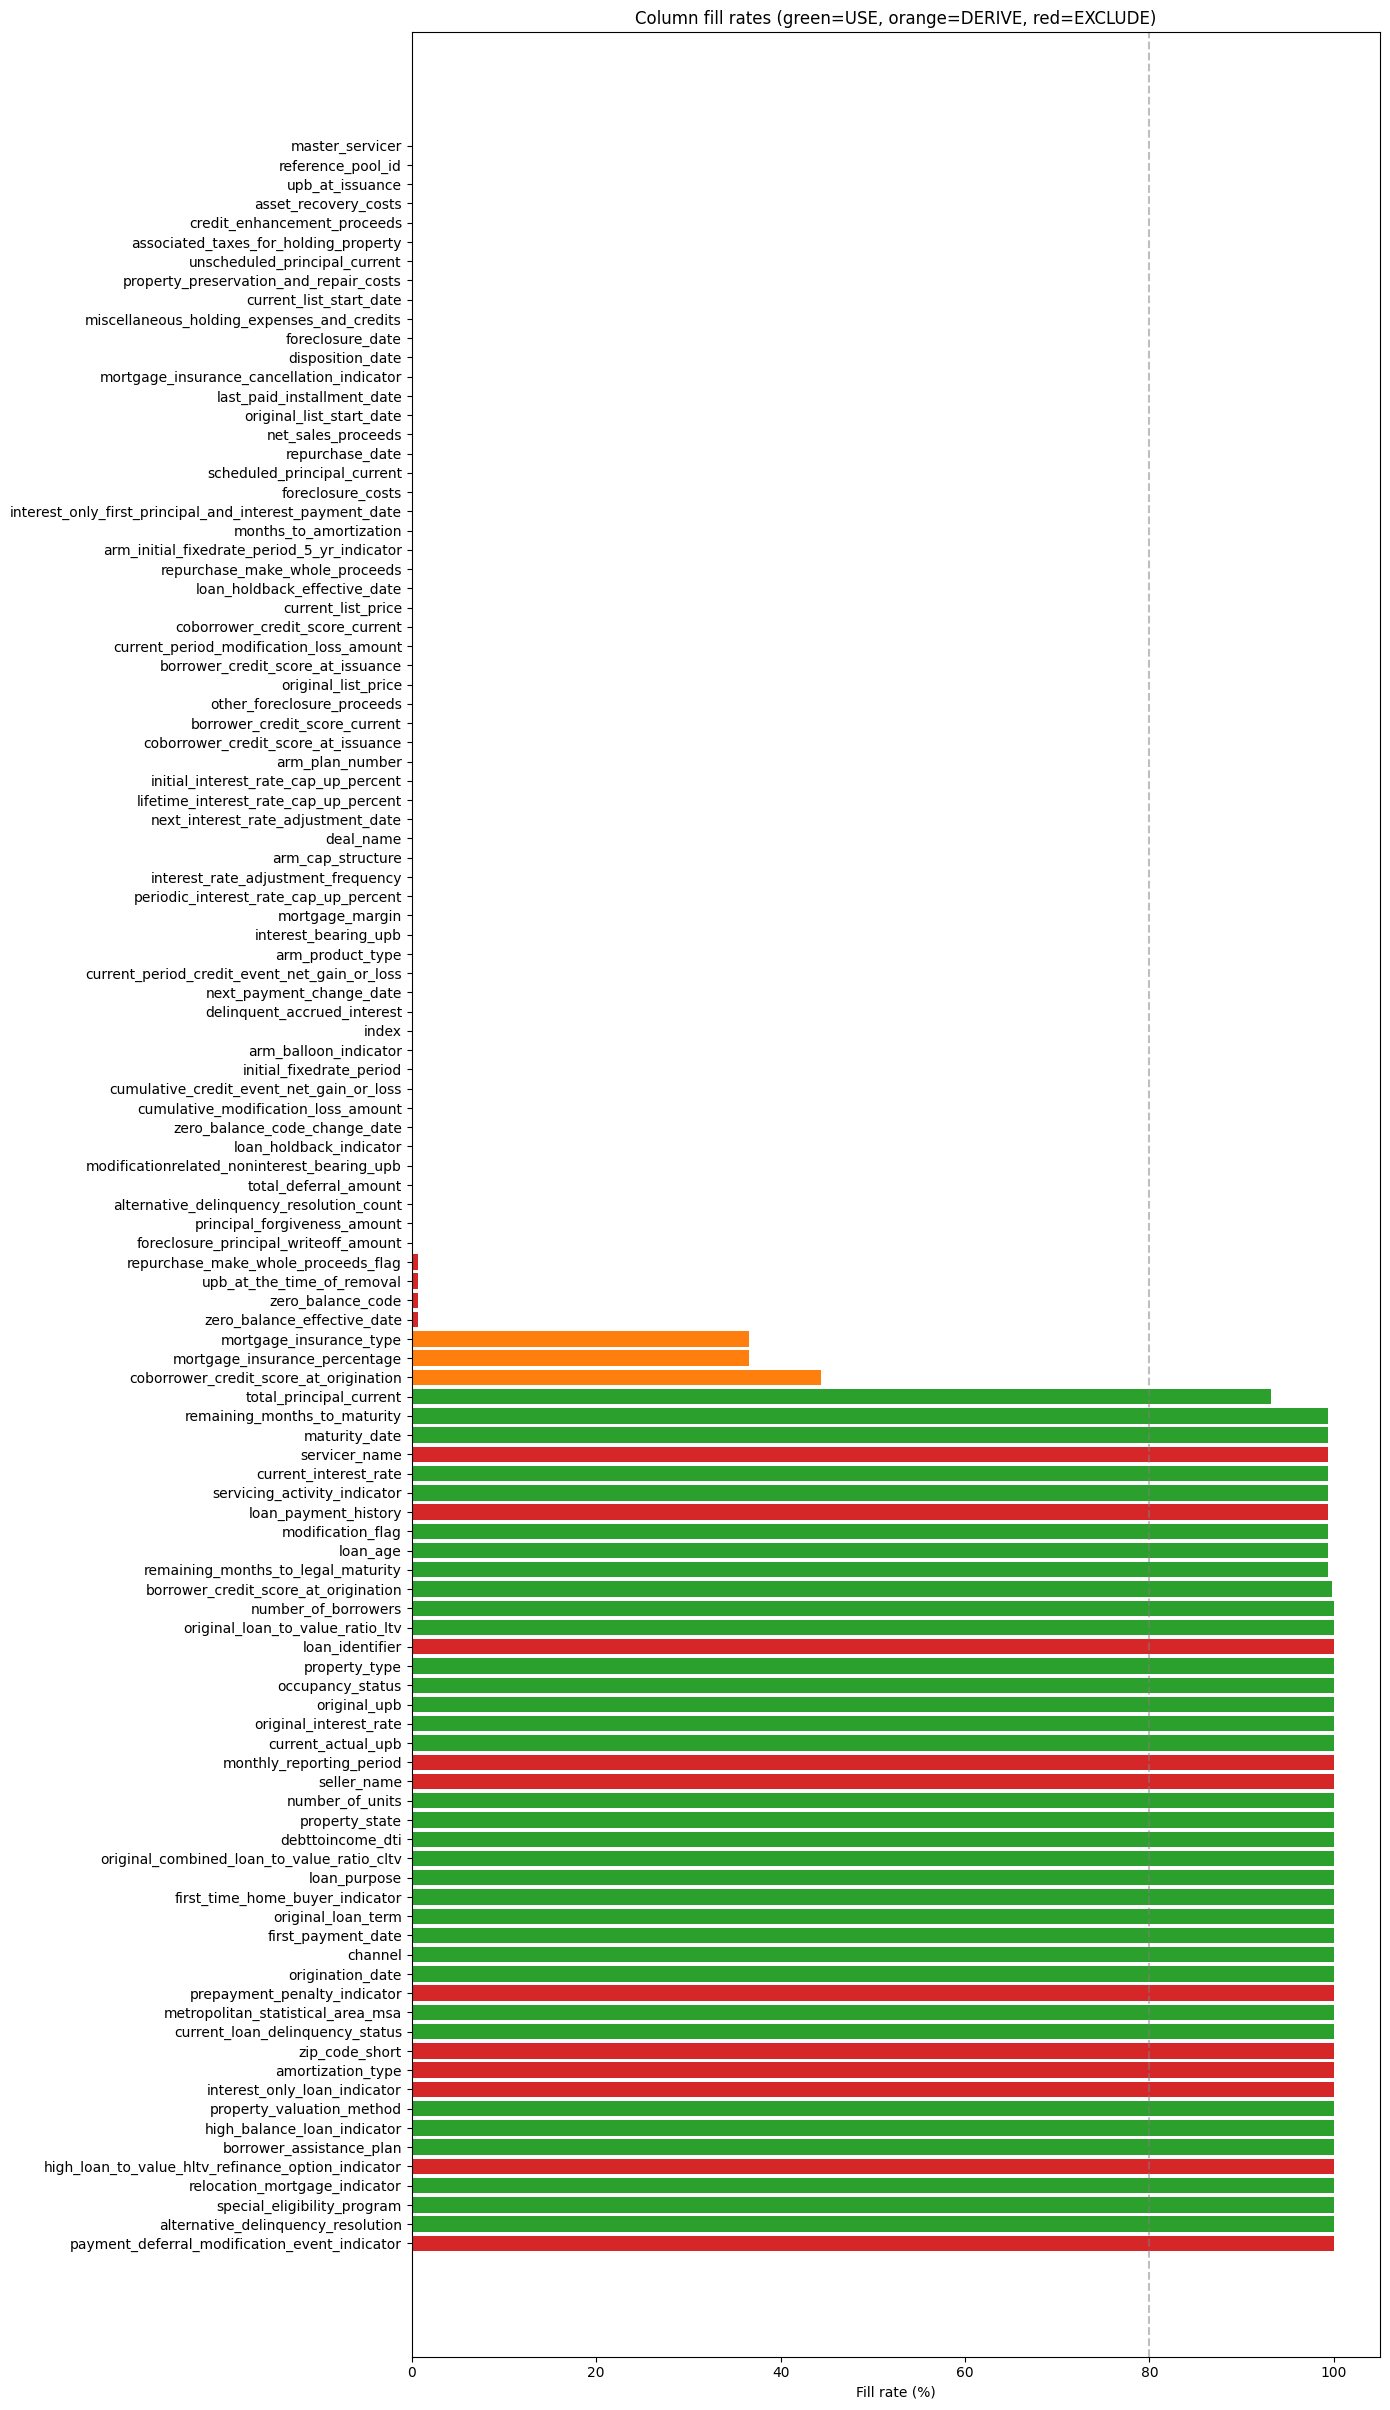

In [15]:
# 2.2 — Visual: fill rates across all columns (sorted)

fig, ax = plt.subplots(figsize=(14, max(6, len(quality)*0.22)))
colors = quality["decision"].map({"USE":"#2ca02c", "DERIVE":"#ff7f0e", "EXCLUDE":"#d62728"})
ax.barh(quality["column_name"], quality["fill_pct"], color=colors)
ax.set_xlabel("Fill rate (%)")
ax.set_title("Column fill rates (green=USE, orange=DERIVE, red=EXCLUDE)")
ax.axvline(80, color="gray", linestyle="--", alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/B2_fill_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# 2.3 — Summary: columns selected for the study
#
# This produces the definitive feature list, which will map into the
# financial-logistics components (Nodes / Arcs / Buffers / Disruptions).

usable = quality[quality["decision"].isin(["USE","DERIVE"])]["column_name"].tolist()
print(f"Columns available for modeling: {len(usable)}")
for c in usable:
    print(f"  • {c}  ({quality.loc[quality['column_name']==c, 'reason'].iloc[0]})")

Columns available for modeling: 37
  • mortgage_insurance_type  (moderate fill (36.6%); needs imputation/flag)
  • mortgage_insurance_percentage  (moderate fill (36.6%); needs imputation/flag)
  • coborrower_credit_score_at_origination  (moderate fill (44.4%); needs imputation/flag)
  • total_principal_current  (good quality (fill=93.1%, distinct=581063))
  • remaining_months_to_maturity  (good quality (fill=99.3%, distinct=360))
  • maturity_date  (good quality (fill=99.3%, distinct=300))
  • current_interest_rate  (good quality (fill=99.3%, distinct=2292))
  • servicing_activity_indicator  (good quality (fill=99.3%, distinct=2))
  • modification_flag  (good quality (fill=99.3%, distinct=2))
  • loan_age  (good quality (fill=99.3%, distinct=38))
  • remaining_months_to_legal_maturity  (good quality (fill=99.3%, distinct=335))
  • borrower_credit_score_at_origination  (good quality (fill=99.8%, distinct=322))
  • number_of_borrowers  (good quality (fill=100.0%, distinct=6))
  • origina

---
# ════════════════════════════════════════════════════
# BLOCK 3 — EMPIRICAL PART (METHODOLOGY-ALIGNED)
# ════════════════════════════════════════════════════

Strict pipeline following the article's **MODEL ARCHITECTURE** (Section 4) and **EXPERIMENTAL SETUP** (Section 5):

1. **3.1** — Feature engineering & Financial-Logistics mapping
2. **3.2** — Panel construction (SQL views)
3. **3.3** — Data splitting (temporal, no leakage)
4. **3.4** — Baseline models (Logistic Regression, GBDT, Cox PH, Static NN)
5. **3.5** — RNN Hazard model (GRU/LSTM)
6. **3.6** — Evaluation metrics (ROC-AUC, PR-AUC, Precision@k, Brier, Time-dep AUC)
7. **3.7** — Ablation analysis (group masking by component)
8. **3.8** — Export results for article

In [17]:
# 3.1 — Feature-to-Component Mapping (Table 1 of the article)
#
# Formal mapping M: X_j → C_k ∈ {Node, Arc, Buffer, Disruption}
# following Section III.G / III.H of the paper.

# ── MAPPING DEFINITION ──
# Each entry: (fannie_mae_column_resolved, component, functional_role, rationale)

FEATURE_MAP_RAW = [
    # ═══ NODES (structural state of the borrower) ═══
    (ltv_col,    "Node", "Structural leverage",
     "Original debt-to-asset configuration"),
    (cltv_col,   "Node", "Combined leverage",
     "Total leverage including subordinate liens"),
    (dti_col,    "Node", "Structural debt burden",
     "Debt load as share of income at origination"),
    (fico_col,   "Node", "Credit profile",
     "Static creditworthiness proxy"),
    (orig_upb,   "Node", "Debt structure",
     "Original obligation size"),
    (term_col,   "Node", "Contract structure",
     "Loan maturity; defines repayment schedule"),
    (rate_col,   "Node", "Cost of debt",
     "Current interest rate; quasi-static for FRM"),

    # ═══ ARCS (cash flow dynamics) ═══
    (upb_col,    "Arc", "Outstanding balance",
     "Current debt level; changes reflect principal flows"),
    (sch_prin,   "Arc", "Scheduled principal flow",
     "Contractual principal amortization intensity"),
    (tot_prin,   "Arc", "Total principal flow",
     "Realized principal payment (scheduled + unscheduled)"),
    (unsch_prin, "Arc", "Unscheduled principal flow",
     "Prepayment component; excess cash flow intensity"),

    # ═══ BUFFERS (financial stability reserves) ═══
    # Derived features (computed in SQL view below)
    ("amort_buffer",  "Buffer", "Amortization buffer",
     "Ratio of scheduled principal to UPB — repayment pace"),
    (defer_col,       "Buffer", "Deferral capacity",
     "Deferred amount = implicit liquidity reserve"),
    (mi_col,          "Buffer", "Insurance reserve",
     "MI percentage provides loss absorption capacity"),
    (fico_cur,        "Buffer", "Current credit health",
     "Updated FICO; reflects borrower's current resilience"),

    # ═══ DISRUPTIONS (instability / shocks) ═══
    (dq_col,     "Disruption", "Payment breakdown",
     "Delinquency status = direct disruption measure"),
    ("dq_change_1m",  "Disruption", "Flow degradation speed",
     "Δ delinquency month-over-month"),
    ("roll_worse_1m", "Disruption", "Roll-forward indicator",
     "Binary: delinquency worsened"),
    ("cure_1m",       "Disruption", "Self-correction signal",
     "Binary: borrower cured (improvement)"),
    ("dq_mean_3m",    "Disruption", "Sustained instability",
     "3-month rolling mean of delinquency"),
    ("dq_std_3m",     "Disruption", "Instability volatility",
     "3-month volatility of delinquency status"),
    (mod_col,         "Disruption", "Modification signal",
     "Loan modified = prior stress event"),
    (delin_int,       "Disruption", "Accrued disruption cost",
     "Delinquent interest = cumulative disruption effect"),
]

# Filter out None (missing columns)
FEATURE_MAP = [(c, comp, role, rat) for c, comp, role, rat in FEATURE_MAP_RAW if c is not None]

mapping_df = pd.DataFrame(FEATURE_MAP, columns=["feature","component","functional_role","rationale"])
display(mapping_df)
mapping_df.to_csv("outputs/C1_feature_component_mapping.csv", index=False)

# Feature groups (for ablation)
feature_groups = {}
for comp in ["Node","Arc","Buffer","Disruption"]:
    feature_groups[comp] = mapping_df[mapping_df["component"]==comp]["feature"].tolist()

print("\n=== Feature groups for ablation ===")
for g, feats in feature_groups.items():
    print(f"  {g}: {feats}")

,feature,component,functional_role,rationale
0,original_loan_to_value_ratio_ltv,Node,Structural leverage,Original debt-to-asset configuration
1,original_combined_loan_to_value_ratio_cltv,Node,Combined leverage,Total leverage including subordinate liens
2,debttoincome_dti,Node,Structural debt burden,Debt load as share of income at origination
3,borrower_credit_score_at_origination,Node,Credit profile,Static creditworthiness proxy
4,original_upb,Node,Debt structure,Original obligation size
5,original_loan_term,Node,Contract structure,Loan maturity; defines repayment schedule
6,current_interest_rate,Node,Cost of debt,Current interest rate; quasi-static for FRM
7,current_actual_upb,Arc,Outstanding balance,Current debt level; changes reflect principal ...
8,scheduled_principal_current,Arc,Scheduled principal flow,Contractual principal amortization intensity
9,total_principal_current,Arc,Total principal flow,Realized principal payment (scheduled + unsche...



=== Feature groups for ablation ===
  Node: ['original_loan_to_value_ratio_ltv', 'original_combined_loan_to_value_ratio_cltv', 'debttoincome_dti', 'borrower_credit_score_at_origination', 'original_upb', 'original_loan_term', 'current_interest_rate']
  Arc: ['current_actual_upb', 'scheduled_principal_current', 'total_principal_current', 'unscheduled_principal_current']
  Buffer: ['amort_buffer', 'total_deferral_amount', 'mortgage_insurance_percentage', 'borrower_credit_score_current']
  Disruption: ['current_loan_delinquency_status', 'dq_change_1m', 'roll_worse_1m', 'cure_1m', 'dq_mean_3m', 'dq_std_3m', 'modification_flag', 'delinquent_accrued_interest']


In [ ]:
# 3.2 — Panel construction: materialized tables + derived-feature views
#
# PERFORMANCE STRATEGY:
#   fm_panel_base  (TABLE)  — cleaned, typed panel with composite index
#   fm_labels      (TABLE)  — loan-level default/censoring with unique index
#   fm_features_3m (VIEW)   — window functions over indexed table (fast)
#   fm_analysis    (VIEW)   — join features + labels + event flag
#   fm_baseline_12m(VIEW)   — 12-month forward default label
#
# Materializing base layers eliminates cascading full-scans.
# Expected: VIEW→VIEW→VIEW chain (30+ min) → TABLE+index (2-5 min).

import time as _time
_t0 = _time.time()

def qc(c):
    return f'\"{c}\"' if c else 'NULL'

# ─── Cleanup (reverse dependency order) ───
for ddl in [
    "DROP MATERIALIZED VIEW IF EXISTS public.fm_rnn_source CASCADE",
    "DROP VIEW IF EXISTS public.fm_baseline_12m CASCADE",
    "DROP VIEW IF EXISTS public.fm_analysis CASCADE",
    "DROP VIEW IF EXISTS public.fm_features_3m CASCADE",
    "DROP TABLE IF EXISTS public.fm_labels CASCADE",
    "DROP TABLE IF EXISTS public.fm_panel_base CASCADE",
    "DROP TABLE IF EXISTS public.fm_loan_sample CASCADE",
    "DROP MATERIALIZED VIEW IF EXISTS public.fm_rnn_source_sample CASCADE",
]:
    exec_sql(ddl)

# ─── 1) fm_panel_base — MATERIALIZED TABLE ───
exec_sql(f"""
CREATE TABLE public.fm_panel_base AS
SELECT
  {qc(loan_col)}::text                            AS loan_id,
  ({month_expr})                                   AS month,
  ({dq_expr})                                      AS dq_m,
  {qc(rate_col) if rate_col else "NULL"}::numeric  AS rate,
  {qc(ltv_col)  if ltv_col  else "NULL"}::numeric  AS ltv,
  {qc(cltv_col) if cltv_col else "NULL"}::numeric  AS cltv,
  {qc(dti_col)  if dti_col  else "NULL"}::numeric  AS dti,
  {qc(fico_col) if fico_col else "NULL"}::numeric  AS fico_orig,
  {qc(fico_cur) if fico_cur else "NULL"}::numeric  AS fico_cur,
  {qc(orig_upb) if orig_upb else "NULL"}::numeric  AS orig_upb,
  {qc(upb_col)  if upb_col  else "NULL"}::numeric  AS current_upb,
  {qc(term_col) if term_col else "NULL"}::numeric  AS loan_term,
  {qc(sch_prin) if sch_prin else "NULL"}::numeric  AS sch_prin,
  {qc(tot_prin) if tot_prin else "NULL"}::numeric  AS tot_prin,
  {qc(unsch_prin) if unsch_prin else "NULL"}::numeric AS unsch_prin,
  {qc(delin_int) if delin_int else "NULL"}::numeric   AS delin_int,
  {qc(defer_col) if defer_col else "NULL"}::numeric   AS deferral_amt,
  CASE WHEN {qc(defer_col) if defer_col else "NULL"}::numeric > 0 THEN 1 ELSE 0 END AS deferral_flag,
  CASE WHEN UPPER({qc(mod_col) if mod_col else "'N'"}::text) = 'Y' THEN 1 ELSE 0 END AS mod_flag,
  {qc(mi_col) if mi_col else "NULL"}::numeric AS mi_pct,
  {qc(zb_col) if zb_col else "NULL"}::text    AS zero_balance_code
FROM {SCHEMA}.\"{RAW_TABLE}\"
WHERE {qc(loan_col)} IS NOT NULL
  AND ({month_expr}) IS NOT NULL;
""")

# Critical indexes
exec_sql("CREATE INDEX ix_pb_lid_month ON public.fm_panel_base (loan_id, month);")
exec_sql("CREATE INDEX ix_pb_lid       ON public.fm_panel_base (loan_id);")
exec_sql("ANALYZE public.fm_panel_base;")

n_rows = q("SELECT COUNT(*) AS n FROM public.fm_panel_base;").iloc[0,0]
print(f"✓ fm_panel_base TABLE: {int(n_rows):,} rows  ({_time.time()-_t0:.1f}s)")

# ─── 2) fm_labels — MATERIALIZED TABLE ───
_t1 = _time.time()
exec_sql(f"""
CREATE TABLE public.fm_labels AS
WITH first_default AS (
  SELECT loan_id, MIN(month) AS default_month
  FROM public.fm_panel_base
  WHERE dq_m >= {DEFAULT_DQ_THRESHOLD}
  GROUP BY loan_id
)
SELECT
  b.loan_id,
  d.default_month,
  CASE WHEN d.default_month IS NOT NULL THEN 0 ELSE 1 END AS censored
FROM (SELECT DISTINCT loan_id FROM public.fm_panel_base) b
LEFT JOIN first_default d USING (loan_id);
""")
exec_sql("CREATE UNIQUE INDEX ix_lbl_lid ON public.fm_labels (loan_id);")
exec_sql("ANALYZE public.fm_labels;")

lbl = q("SELECT COUNT(*) AS n, SUM(CASE WHEN censored=0 THEN 1 ELSE 0 END) AS n_def FROM public.fm_labels;")
n_loans = int(lbl.iloc[0]["n"]); n_def = int(lbl.iloc[0]["n_def"])
print(f"✓ fm_labels TABLE: {n_loans:,} loans, {n_def:,} defaulted ({n_def/n_loans*100:.4f}%)  ({_time.time()-_t1:.1f}s)")

# ─── 3) fm_features_3m — VIEW (window funcs over indexed TABLE) ───
exec_sql("""
CREATE OR REPLACE VIEW public.fm_features_3m AS
SELECT
  loan_id, month, dq_m,
  dq_m - LAG(dq_m, 1) OVER w                  AS dq_change_1m,
  CASE WHEN dq_m > COALESCE(LAG(dq_m, 1) OVER w, 0) THEN 1 ELSE 0 END AS roll_worse_1m,
  CASE WHEN dq_m < COALESCE(LAG(dq_m, 1) OVER w, 0) THEN 1 ELSE 0 END AS cure_1m,
  AVG(dq_m)    OVER (PARTITION BY loan_id ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS dq_mean_3m,
  STDDEV(dq_m) OVER (PARTITION BY loan_id ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS dq_std_3m,
  CASE WHEN current_upb > 0 THEN sch_prin / current_upb ELSE NULL END AS amort_buffer,
  current_upb - LAG(current_upb, 1) OVER w     AS upb_change_1m,
  rate, ltv, cltv, dti, fico_orig, fico_cur,
  orig_upb, current_upb, loan_term,
  sch_prin, tot_prin, unsch_prin, delin_int,
  deferral_amt, deferral_flag, mod_flag, mi_pct,
  zero_balance_code
FROM public.fm_panel_base
WINDOW w AS (PARTITION BY loan_id ORDER BY month);
""")
print("✓ fm_features_3m VIEW")

# ─── 4) fm_analysis — VIEW ───
exec_sql("""
CREATE OR REPLACE VIEW public.fm_analysis AS
SELECT
  f.*,
  l.default_month,
  CASE WHEN l.default_month IS NOT NULL AND f.month = l.default_month THEN 1 ELSE 0 END AS event
FROM public.fm_features_3m f
JOIN public.fm_labels l USING (loan_id);
""")
print("✓ fm_analysis VIEW")

# ─── 5) fm_baseline_12m — VIEW ───
exec_sql("""
CREATE OR REPLACE VIEW public.fm_baseline_12m AS
SELECT
  f.loan_id, f.month,
  CASE WHEN l.default_month IS NOT NULL
        AND l.default_month > f.month
        AND l.default_month <= (f.month + interval '12 months')
       THEN 1 ELSE 0 END AS y12
FROM public.fm_panel_base f
JOIN public.fm_labels l USING (loan_id);
""")
print("✓ fm_baseline_12m VIEW")
print(f"\n=== All SQL objects ready ({_time.time()-_t0:.1f}s total) ===")


In [17]:
# 3.2b — Sanity checks

print("=== Panel base ===")
display(q("""
  SELECT MIN(month) AS min_m, MAX(month) AS max_m,
         COUNT(*) AS n_rows, COUNT(DISTINCT loan_id) AS n_loans
  FROM public.fm_panel_base;
"""))

print("\n=== Labels ===")
display(q("""
  SELECT COUNT(*) AS n_loans,
    SUM(CASE WHEN censored=0 THEN 1 ELSE 0 END) AS n_defaulted,
    ROUND(AVG(CASE WHEN censored=0 THEN 1.0 ELSE 0.0 END)*100, 4) AS default_rate_pct
  FROM public.fm_labels;
"""))

print("\n=== fm_analysis sample (5 rows) ===")
display(q("SELECT * FROM public.fm_analysis LIMIT 5;"))

print("\n=== Delinquency distribution in panel ===")
display(q("""
  SELECT dq_m, COUNT(*) AS n_obs,
    ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 3) AS pct
  FROM public.fm_panel_base WHERE dq_m IS NOT NULL
  GROUP BY dq_m ORDER BY dq_m;
"""))


=== Panel base ===


,min_m,max_m,n_rows,n_loans
0,2024-01-01,2025-09-01,14130111,970976



=== Labels ===


,n_loans,n_defaulted,default_rate_pct
0,970976,6145,0.6329



=== fm_analysis sample (5 rows) ===


,loan_id,month,dq_m,dq_change_1m,roll_worse_1m,cure_1m,dq_mean_3m,dq_std_3m,amort_buffer,upb_change_1m,...,tot_prin,unsch_prin,delin_int,deferral_amt,deferral_flag,mod_flag,mi_pct,zero_balance_code,default_month,event
0,000137581448,2024-01-01,0,NaN,0,0,0.0,NaN,None,NaN,...,NaN,None,None,None,0,0,None,None,None,0
1,000137581448,2024-02-01,0,0.0,0,0,0.0,0.0,None,0.0,...,0.00,None,None,None,0,0,None,None,None,0
2,000137581448,2024-03-01,0,0.0,0,0,0.0,0.0,None,-1000.0,...,773.58,None,None,None,0,0,None,None,None,0
3,000137581448,2024-04-01,0,0.0,0,0,0.0,0.0,None,0.0,...,374.10,None,None,None,0,0,None,None,None,0
4,000137581448,2024-05-01,0,0.0,0,0,0.0,0.0,None,0.0,...,0.00,None,None,None,0,0,None,None,None,0



=== Delinquency distribution in panel ===


,dq_m,n_obs,pct
0,0,14016151,99.193
1,1,72610,0.514
2,2,15892,0.112
3,3,7610,0.054
4,4,5021,0.036
5,5,3741,0.026
6,6,2607,0.018
7,7,1869,0.013
8,8,1428,0.010
9,9,1019,0.007


In [18]:
# 3.2c — Materialize full analysis panel
#
# Full dataset — no sampling. Materializing the VIEW chain into a single
# TABLE with pre-computed t (time index) and T_cnt (sequence length).
# This is the single data source for all downstream modeling.
#
# NOTE: This replaces the previous sample-based approach.
# We work on the FULL population to preserve natural default rate.

import time as _time
_t0 = _time.time()

exec_sql("DROP MATERIALIZED VIEW IF EXISTS public.fm_rnn_source CASCADE;")

exec_sql("""
CREATE MATERIALIZED VIEW public.fm_rnn_source AS
SELECT
  a.*,
  (ROW_NUMBER() OVER (PARTITION BY a.loan_id ORDER BY a.month) - 1) AS t,
  COUNT(*) OVER (PARTITION BY a.loan_id) AS t_cnt
FROM public.fm_analysis a
WHERE a.month IS NOT NULL;
""")

exec_sql("CREATE INDEX ix_rnn_lid_month ON public.fm_rnn_source (loan_id, month);")
exec_sql("CREATE INDEX ix_rnn_lid       ON public.fm_rnn_source (loan_id);")
exec_sql("CREATE INDEX ix_rnn_tcnt      ON public.fm_rnn_source (t_cnt);")
exec_sql("ANALYZE public.fm_rnn_source;")

stats = q("""
  SELECT COUNT(*) AS n_rows,
         COUNT(DISTINCT loan_id) AS n_loans,
         SUM(event) AS n_events,
         ROUND(AVG(event::numeric)*100, 5) AS event_rate_pct
  FROM public.fm_rnn_source;
""")
display(stats)
print(f"\n✓ fm_rnn_source materialized ({_time.time()-_t0:.1f}s)")


,n_rows,n_loans,n_events,event_rate_pct
0,14130111,970976,6145,0.04349



✓ fm_rnn_source materialized (241.0s)


In [ ]:
# 3.3 — Load panel data & define feature columns
#
# Feature vector X_i(t) = [V_i(t), F_i(t), B_i(t), D_i(t)]
# per article Section IV.B

import gc

# Feature lists by financial-logistics component
feat_nodes = ["rate","ltv","cltv","dti","fico_orig","orig_upb","loan_term"]
feat_arcs  = ["current_upb","sch_prin","tot_prin","unsch_prin","upb_change_1m"]
feat_bufs  = ["amort_buffer","deferral_amt","deferral_flag","mi_pct","fico_cur"]
feat_disr  = ["dq_m","dq_change_1m","roll_worse_1m","cure_1m","dq_mean_3m","dq_std_3m","mod_flag","delin_int"]

feature_cols = feat_nodes + feat_arcs + feat_bufs + feat_disr

# Groups for ablation (by index in feature_cols)
group_indices = {
    "Nodes (V)":       [feature_cols.index(c) for c in feat_nodes],
    "Arcs (F)":        [feature_cols.index(c) for c in feat_arcs],
    "Buffers (B)":     [feature_cols.index(c) for c in feat_bufs],
    "Disruptions (D)": [feature_cols.index(c) for c in feat_disr],
}

print(f"Total features: {len(feature_cols)}")
for g, idx in group_indices.items():
    print(f"  {g}: {len(idx)} — {[feature_cols[i] for i in idx]}")

# ─── Check which features exist in MV ───
src_cols = q("""
  SELECT column_name FROM information_schema.columns
  WHERE table_schema='public' AND table_name='fm_rnn_source';
""")["column_name"].tolist()

available = [c for c in feature_cols if c in src_cols]
missing   = [c for c in feature_cols if c not in src_cols]
if missing:
    print(f"\nWARNING: missing in MV (will fill 0): {missing}")

select_cols = [f'"{c}"' if c in available else f'0::numeric AS "{c}"' for c in feature_cols]

# ─── Load full panel (only loans with >= SEQ_L months) ───
import time as _time
_t0 = _time.time()

sql = f"""
SELECT loan_id, month, event, default_month, t,
       {", ".join(select_cols)}
FROM public.fm_rnn_source
WHERE t_cnt >= {SEQ_L}
ORDER BY loan_id, month;
"""

rnn_df = q(sql)
print(f"Query time: {_time.time()-_t0:.1f}s")

# Type casting & memory optimization
rnn_df["month"] = pd.to_datetime(rnn_df["month"], errors="coerce")
rnn_df["default_month"] = pd.to_datetime(rnn_df["default_month"], errors="coerce")
for c in feature_cols + ["event", "t"]:
    rnn_df[c] = pd.to_numeric(rnn_df[c], errors="coerce")
rnn_df = rnn_df.dropna(subset=["month"]).fillna(0.0)

# Downcast
for c in feature_cols:
    rnn_df[c] = rnn_df[c].astype("float32")
rnn_df["event"] = rnn_df["event"].astype("int8")
rnn_df["t"]     = rnn_df["t"].astype("int16")

gc.collect()

n_rows = len(rnn_df)
n_loans = rnn_df["loan_id"].nunique()
n_events = int(rnn_df["event"].sum())
mem_mb = rnn_df.memory_usage(deep=True).sum() / 1e6

print(f"\nLoaded: {n_rows:,} rows, {n_loans:,} loans")
print(f"Events (90+ DPD at t): {n_events:,}")
print(f"Memory: {mem_mb:.0f} MB")


Total features: 25
  Nodes (V): 7 — ['rate', 'ltv', 'cltv', 'dti', 'fico_orig', 'orig_upb', 'loan_term']
  Arcs (F): 5 — ['current_upb', 'sch_prin', 'tot_prin', 'unsch_prin', 'upb_change_1m']
  Buffers (B): 5 — ['amort_buffer', 'deferral_amt', 'deferral_flag', 'mi_pct', 'fico_cur']
  Disruptions (D): 8 — ['dq_m', 'dq_change_1m', 'roll_worse_1m', 'cure_1m', 'dq_mean_3m', 'dq_std_3m', 'mod_flag', 'delin_int']



In [ ]:
# 3.3b — Target: one-step discrete-time hazard
#
# y_{i,t}^{next} = 1{first occurrence of dq_m >= 3 happens at t+1}
# Risk set: only months STRICTLY BEFORE first default (Section IV.F)

df_all = rnn_df.copy()
df_all["dq_int"] = df_all["dq_m"].astype(int)

# First-hit event: 1 only at the FIRST month of 90+ DPD
df_all["prev_dq"] = df_all.groupby("loan_id")["dq_int"].shift(1).fillna(0).astype(int)
df_all["event_first"] = ((df_all["dq_int"] >= DEFAULT_DQ_THRESHOLD) &
                         (df_all["prev_dq"] < DEFAULT_DQ_THRESHOLD)).astype("int8")

# Time of first default per loan
t_first = (
    df_all.loc[df_all["event_first"]==1, ["loan_id","t"]]
    .groupby("loan_id", as_index=False)["t"].min()
    .rename(columns={"t": "t_first_default"})
)
df_all = df_all.merge(t_first, on="loan_id", how="left")
df_all["t_first_default"] = df_all["t_first_default"].fillna(np.inf)

# y_next = event_first shifted by -1 (target for hazard model)
df_all["y_next"] = df_all.groupby("loan_id")["event_first"].shift(-1)

# Risk set: months before first default, with valid y_next
df_full = df_all[df_all["t"] < df_all["t_first_default"]].copy()
df_full = df_full.dropna(subset=["y_next"]).copy()
df_full["y_next"] = df_full["y_next"].astype("int8")

# Filter: need >= SEQ_L months of history
df0 = df_full[df_full["t"] >= (SEQ_L - 1)].copy()

# Save default_month_first for hazard profile later
default_month_tbl = (
    df_all.loc[df_all["event_first"]==1, ["loan_id","month"]]
    .groupby("loan_id", as_index=False)["month"].min()
    .rename(columns={"month": "default_month_first"})
)

# Free memory
del df_all; gc.collect()

print(f"Full risk set:  {len(df_full):,} obs, {df_full['loan_id'].nunique():,} loans")
print(f"With history:   {len(df0):,} obs (t >= {SEQ_L-1})")
print(f"Positive rate:  {df0['y_next'].mean():.6f}  ({int(df0['y_next'].sum()):,} events)")


In [ ]:
# 3.3c — Data split (by loan_id, no leakage)
#
# Section V.B: deterministic hash-based split.
# 80% train / 10% val / 10% test — no temporal leakage.

import hashlib

def split_bucket(lid):
    return int(hashlib.md5(str(lid).encode()).hexdigest()[:8], 16) % 100

loan_ids = df_full["loan_id"].drop_duplicates()
buckets  = loan_ids.map(split_bucket)
loan_split = pd.DataFrame({"loan_id": loan_ids.values, "bucket": buckets.values})
loan_split["split"] = np.where(
    loan_split["bucket"] < 80, "train",
    np.where(loan_split["bucket"] < 90, "val", "test")
)

df_full = df_full.merge(loan_split[["loan_id","split"]], on="loan_id", how="left")
df0     = df0.merge(loan_split[["loan_id","split"]], on="loan_id", how="left")

print("=== Split sizes (with SEQ_L history) ===")
for sp in ["train","val","test"]:
    sub = df0[df0["split"]==sp]
    print(f"  {sp:5s}: {len(sub):>10,} obs | {sub['loan_id'].nunique():>8,} loans | pos_rate={sub['y_next'].mean():.6f}")


In [ ]:
# 3.4 — Baseline models (Section V.C)
#
# All baselines from article Table 1:
#   (1) Logistic Regression
#   (2) Random Forest
#   (3) Gradient Boosting (GBDT)
#   (4) Cox Proportional Hazards
#   (5) Static Neural Network (MLP)
#
# All use SNAPSHOT features (current month) to predict y_next.
# Cox PH uses loan-level (duration, event) with snapshot covariates.

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def eval_binary(y_true, y_prob, name="model"):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_pos = y_true.sum()
    if n_pos == 0 or n_pos == len(y_true):
        return {"model": name, "roc_auc": np.nan, "pr_auc": np.nan, "brier": np.nan}
    return {
        "model": name,
        "roc_auc": round(roc_auc_score(y_true, y_prob), 5),
        "pr_auc":  round(average_precision_score(y_true, y_prob), 5),
        "brier":   round(brier_score_loss(y_true, y_prob), 6),
    }

def lift_at_k(y_true, y_prob, k=0.05):
    n = len(y_true); m = max(int(n*k), 1)
    top = np.argsort(-y_prob)[:m]
    recall = y_true[top].sum() / max(y_true.sum(), 1)
    precision = y_true[top].mean()
    return float(recall), float(precision)

# ── Prepare datasets ──
train_df = df0[df0["split"]=="train"]
val_df   = df0[df0["split"]=="val"]
test_df  = df0[df0["split"]=="test"]

X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df["y_next"].values.astype(int)
X_val   = val_df[feature_cols].values.astype("float32")
y_val   = val_df["y_next"].values.astype(int)
X_test  = test_df[feature_cols].values.astype("float32")
y_test  = test_df["y_next"].values.astype(int)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Test pos rate: {y_test.mean():.6f} ({y_test.sum():,} events)")

# Scaler for models that need it
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

baseline_preds = {}  # name → test predictions

# ── (1) Logistic Regression ──
print("\n--- Logistic Regression ---")
logit = LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs", n_jobs=-1)
logit.fit(X_train_sc, y_train)
baseline_preds["Logistic Regression"] = logit.predict_proba(X_test_sc)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Logistic Regression']):.5f}")

# ── (2) Random Forest ──
print("\n--- Random Forest ---")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=50,
    class_weight="balanced", n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
baseline_preds["Random Forest"] = rf.predict_proba(X_test)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Random Forest']):.5f}")

# ── (3) Gradient Boosting (GBDT) ──
print("\n--- Gradient Boosting ---")
gbdt = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.05, max_iter=300,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=10, random_state=SEED
)
gbdt.fit(X_train, y_train)
baseline_preds["Gradient Boosting"] = gbdt.predict_proba(X_test)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Gradient Boosting']):.5f}")

# ── (4) Cox Proportional Hazards ──
print("\n--- Cox PH (via lifelines) ---")
try:
    from lifelines import CoxPHFitter
    
    # Loan-level: for each loan, take the LAST observation in risk set
    # Duration = t (months since first observation)
    # Event = 1 if loan eventually defaults
    cox_df = df0.groupby("loan_id").agg(
        duration=("t", "max"),
        event_observed=("y_next", "max"),
        split=("split", "first"),
        **{c: (c, "last") for c in feature_cols}
    ).reset_index()
    cox_df["duration"] = cox_df["duration"] + 1  # avoid zero durations
    
    cox_train = cox_df[cox_df["split"]=="train"][["duration","event_observed"] + feature_cols].copy()
    cox_test  = cox_df[cox_df["split"]=="test"][["duration","event_observed"] + feature_cols].copy()
    
    # Standardize features for Cox
    for c in feature_cols:
        mu, sd = cox_train[c].mean(), cox_train[c].std()
        sd = max(sd, 1e-8)
        cox_train[c] = (cox_train[c] - mu) / sd
        cox_test[c]  = (cox_test[c] - mu) / sd
    
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(cox_train, duration_col="duration", event_col="event_observed")
    
    # Risk score (higher = more risk) → use as probability proxy
    # Note: Cox PH is loan-level, not observation-level like others
    cox_risk = cph.predict_partial_hazard(cox_test[feature_cols]).values.flatten()
    cox_y    = cox_test["event_observed"].values.astype(int)
    
    # Store for loan-level comparison
    baseline_preds["Cox PH"] = None  # handled separately (loan-level)
    cox_roc = roc_auc_score(cox_y, cox_risk) if cox_y.sum() > 0 else np.nan
    cox_pr  = average_precision_score(cox_y, cox_risk) if cox_y.sum() > 0 else np.nan
    print(f"  ROC-AUC (loan-level): {cox_roc:.5f}")
    
    del cox_df, cox_train; gc.collect()
    HAS_COX = True
    
except ImportError:
    print("  lifelines not installed — pip install lifelines")
    print("  Skipping Cox PH")
    HAS_COX = False
except Exception as e:
    print(f"  Cox PH failed: {e}")
    HAS_COX = False

# ── (5) Static Neural Network (MLP) ──
print("\n--- Static NN (MLP) ---")
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MLP(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

mlp = MLP(len(feature_cols)).to(DEVICE)
pos_rate = y_train.mean()
pw = torch.tensor([(1-pos_rate)/max(pos_rate,1e-8)], dtype=torch.float32).to(DEVICE)
mlp_crit = nn.BCEWithLogitsLoss(pos_weight=pw)
mlp_opt  = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)

# DataLoaders
trn_ds = TensorDataset(torch.tensor(X_train_sc, dtype=torch.float32),
                       torch.tensor(y_train, dtype=torch.float32))
val_ds_mlp = TensorDataset(torch.tensor(X_val_sc, dtype=torch.float32),
                           torch.tensor(y_val, dtype=torch.float32))
trn_dl = DataLoader(trn_ds, batch_size=1024, shuffle=True)
val_dl = DataLoader(val_ds_mlp, batch_size=2048, shuffle=False)

import copy
best_mlp_loss = np.inf; best_mlp_state = None; pat = 0
for epoch in range(1, 31):
    mlp.train()
    for xb, yb in trn_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        mlp_opt.zero_grad()
        loss = mlp_crit(mlp(xb), yb)
        loss.backward(); mlp_opt.step()
    mlp.eval()
    with torch.no_grad():
        vl = sum(mlp_crit(mlp(xb.to(DEVICE)), yb.to(DEVICE)).item()*len(xb) for xb,yb in val_dl)
        vl /= len(val_ds_mlp)
    if vl < best_mlp_loss:
        best_mlp_loss = vl; best_mlp_state = copy.deepcopy(mlp.state_dict()); pat=0
    else:
        pat += 1
        if pat >= 5: break
mlp.load_state_dict(best_mlp_state)
mlp.eval()
with torch.no_grad():
    p_mlp = torch.sigmoid(mlp(torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE))).cpu().numpy()
baseline_preds["Static NN"] = p_mlp
print(f"  ROC-AUC: {roc_auc_score(y_test, p_mlp):.5f}")

# ── Summary ──
print("\n=== Baseline summary (observation-level) ===")
baseline_metrics = []
for name, preds in baseline_preds.items():
    if preds is not None:
        baseline_metrics.append(eval_binary(y_test, preds, name))
if HAS_COX:
    baseline_metrics.append({"model": "Cox PH (loan-level)", "roc_auc": round(cox_roc,5),
                             "pr_auc": round(cox_pr,5), "brier": np.nan})
baseline_metrics_df = pd.DataFrame(baseline_metrics)
display(baseline_metrics_df)


In [ ]:
# 3.5 — RNN Hazard Model (Section IV.D–E)
#
# Architecture: GRU(2 layers, h=64) → Linear → σ (one-step hazard)
# Loss: BCE with pos_weight (discrete-time survival, Section IV.F)

import random, copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ── Dataset: sliding windows of length SEQ_L ──
class WindowDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len=12, split="train", mask_idx=None):
        self.feature_cols = feature_cols
        self.seq_len = seq_len
        self.mask_idx = mask_idx
        sub = df[df["split"]==split].sort_values(["loan_id","t"]).reset_index(drop=True)
        self.windows = []
        self.groups  = []
        for lid, g in sub.groupby("loan_id", sort=False):
            X = g[feature_cols].values.astype("float32")
            y = g["y_next"].values.astype("float32")
            month = g["month"].values
            for end in range(self.seq_len-1, len(g)):
                self.windows.append((len(self.groups), end))
            self.groups.append((lid, X, y, month))

    def __len__(self): return len(self.windows)

    def __getitem__(self, idx):
        g_idx, end = self.windows[idx]
        _, X, y, _ = self.groups[g_idx]
        start = end - self.seq_len + 1
        x_seq = np.ascontiguousarray(X[start:end+1])
        if self.mask_idx:
            x_seq = x_seq.copy()
            x_seq[:, self.mask_idx] = 0.0
        return torch.from_numpy(x_seq), torch.tensor(y[end], dtype=torch.float32)

    def get_meta(self, idx):
        g_idx, end = self.windows[idx]
        lid, _, _, month = self.groups[g_idx]
        return lid, month[end]

# ── Model ──
class GRUHazard(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:,-1,:]).squeeze(-1)

# ── Training utilities ──
def make_loader(ds, batch_size=256, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type=="cuda"))

def train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss = 0; n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*len(xb); n += len(xb)
    return total_loss / n

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval(); total_loss = 0; n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        total_loss += criterion(model(xb), yb).item()*len(xb); n += len(xb)
    return total_loss / n

@torch.no_grad()
def predict_loader(model, loader, dataset=None, return_meta=False):
    model.eval()
    ys, ps, lids, months = [], [], [], []
    idx = 0
    for xb, yb in loader:
        prob = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy()
        ys.append(yb.numpy()); ps.append(prob)
        if return_meta and dataset:
            for j in range(len(xb)):
                lid, m = dataset.get_meta(idx+j)
                lids.append(lid); months.append(m)
            idx += len(xb)
    ys = np.concatenate(ys); ps = np.concatenate(ps)
    if return_meta: return ys, ps, lids, months
    return ys, ps

print("✓ RNN utilities defined")


In [ ]:
# 3.5b — Train the RNN hazard model

import time as _time
_t0 = _time.time()

print("Building datasets...")
train_ds = WindowDataset(df_full, feature_cols, seq_len=SEQ_L, split="train")
val_ds   = WindowDataset(df_full, feature_cols, seq_len=SEQ_L, split="val")
test_ds  = WindowDataset(df_full, feature_cols, seq_len=SEQ_L, split="test")
print(f"  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
print(f"  Dataset build time: {_time.time()-_t0:.1f}s")

train_loader = make_loader(train_ds, batch_size=512, shuffle=True)
val_loader   = make_loader(val_ds,   batch_size=1024, shuffle=False)
test_loader  = make_loader(test_ds,  batch_size=1024, shuffle=False)

# Positive weight
pos_rate_rnn = float(df_full[df_full["split"]=="train"]["y_next"].mean())
pos_weight = torch.tensor([(1-pos_rate_rnn)/max(pos_rate_rnn,1e-8)], dtype=torch.float32).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.1f}")

model = GRUHazard(n_features=len(feature_cols), hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

N_EPOCHS = 50; PATIENCE = 7
best_val_loss = np.inf; best_state = None; patience_cnt = 0

for epoch in range(1, N_EPOCHS+1):
    _te = _time.time()
    tr_loss = train_epoch(model, train_loader, optimizer, criterion)
    va_loss = eval_epoch(model, val_loader, criterion)
    elapsed = _time.time() - _te
    if epoch % 3 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | train={tr_loss:.5f} | val={va_loss:.5f} | {elapsed:.1f}s")
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\n✓ Best model restored (total training: {_time.time()-_t0:.1f}s)")


In [ ]:
# 3.6 — Evaluation: Table 1 comparative performance (Section V.D)
#
# Metrics: ROC-AUC, PR-AUC, Brier score, Precision@k

from sklearn.metrics import roc_curve, precision_recall_curve

# ── RNN predictions on test set ──
yt, pt, loan_t, month_t = predict_loader(model, test_loader, dataset=test_ds, return_meta=True)
pred_rnn = pd.DataFrame({"loan_id": loan_t, "month": pd.to_datetime(month_t),
                         "y_true": yt.astype(int), "p_rnn": pt})

print(f"RNN test predictions: {len(pred_rnn):,} obs, pos rate: {pred_rnn['y_true'].mean():.6f}")

# ── Merge all predictions ──
# Baseline preds are aligned with test_df (df0 where split=="test")
# RNN preds are aligned with test_ds windows → need to match on (loan_id, month)
test_ref = test_df[["loan_id","month","y_next"]].copy().reset_index(drop=True)
test_ref["month"] = pd.to_datetime(test_ref["month"])

for name, preds in baseline_preds.items():
    if preds is not None:
        test_ref[f"p_{name}"] = preds

merged = pred_rnn.merge(test_ref, on=["loan_id","month"], how="inner")
print(f"Merged evaluation set: {len(merged):,} obs")

# ── Table 1: all models ──
all_metrics = []
for name in ["Logistic Regression", "Random Forest", "Gradient Boosting", "Static NN"]:
    col = f"p_{name}"
    if col in merged.columns:
        all_metrics.append(eval_binary(merged["y_true"].values, merged[col].values, name))

# Cox PH (loan-level, already computed)
if HAS_COX:
    all_metrics.append({"model": "Cox PH", "roc_auc": round(cox_roc,5),
                        "pr_auc": round(cox_pr,5), "brier": np.nan})

# Proposed RNN
all_metrics.append(eval_binary(merged["y_true"].values, merged["p_rnn"].values,
                               "Proposed Model (RNN-GRU)"))

all_metrics_df = pd.DataFrame(all_metrics)
print("\n══════════════════════════════════════")
print("   TABLE 1: COMPARATIVE PERFORMANCE")
print("══════════════════════════════════════")
display(all_metrics_df)

# ── Lift@k ──
lift_rows = []
model_cols = {name: f"p_{name}" for name in ["Logistic Regression","Random Forest","Gradient Boosting","Static NN"]}
model_cols["Proposed (RNN)"] = "p_rnn"
for name, col in model_cols.items():
    if col in merged.columns:
        for k in [0.01, 0.05, 0.10]:
            rec, prec = lift_at_k(merged["y_true"].values, merged[col].values, k)
            lift_rows.append({"model": name, "k": k, "recall@k": round(rec,4), "precision@k": round(prec,5)})
lift_tbl = pd.DataFrame(lift_rows)
print("\n=== Lift @ k ===")
display(lift_tbl)

# ── ROC & PR curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
curve_models = {"LR": "p_Logistic Regression", "GBDT": "p_Gradient Boosting",
               "Static NN": "p_Static NN", "Proposed": "p_rnn"}
for label, col in curve_models.items():
    if col in merged.columns:
        fpr, tpr, _ = roc_curve(merged["y_true"], merged[col])
        axes[0].plot(fpr, tpr, label=label)
axes[0].plot([0,1],[0,1],"--",color="gray")
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

for label, col in curve_models.items():
    if col in merged.columns:
        pr, rc, _ = precision_recall_curve(merged["y_true"], merged[col])
        axes[1].plot(rc, pr, label=label)
axes[1].set_title("Precision–Recall Curve"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.savefig("outputs/fig_roc_pr_curves.png", dpi=200)
plt.show()


In [ ]:
# 3.7 — Ablation Analysis (Section VI.C)
#
# Group ablation: mask each financial-logistics component → measure performance drop.
# Hypothesis: removing Arcs (flow dynamics) causes the largest drop.

base_pr  = average_precision_score(yt, pt) if len(np.unique(yt))>1 else np.nan
base_roc = roc_auc_score(yt, pt) if len(np.unique(yt))>1 else np.nan

ablation_rows = [{"group": "Full Model", "n_features": len(feature_cols), "n_masked": 0,
                  "pr_auc": base_pr, "roc_auc": base_roc,
                  "delta_pr": 0.0, "delta_roc": 0.0}]

for g_name, g_idx in group_indices.items():
    print(f"  Ablating {g_name} ({len(g_idx)} features)...")
    test_ds.mask_idx = g_idx
    masked_loader = make_loader(test_ds, batch_size=1024, shuffle=False)
    y_m, p_m = predict_loader(model, masked_loader)
    pr_m  = average_precision_score(y_m, p_m) if len(np.unique(y_m))>1 else np.nan
    roc_m = roc_auc_score(y_m, p_m) if len(np.unique(y_m))>1 else np.nan
    ablation_rows.append({
        "group": f"– {g_name}", "n_features": len(feature_cols) - len(g_idx),
        "n_masked": len(g_idx),
        "pr_auc": pr_m, "roc_auc": roc_m,
        "delta_pr": pr_m - base_pr if not np.isnan(pr_m) else np.nan,
        "delta_roc": roc_m - base_roc if not np.isnan(roc_m) else np.nan,
    })

test_ds.mask_idx = None  # reset
ablation_df = pd.DataFrame(ablation_rows)

print("\n══════════════════════════════════════")
print("   TABLE 2: ABLATION ANALYSIS")
print("══════════════════════════════════════")
display(ablation_df)

# Bar chart
abl_plot = ablation_df[ablation_df["group"]!="Full Model"].sort_values("delta_pr")
plt.figure(figsize=(8, 4))
colors = ["#d62728" if d < -0.005 else "#2ca02c" if d > 0.005 else "#999999"
          for d in abl_plot["delta_pr"]]
plt.barh(abl_plot["group"], abl_plot["delta_pr"], color=colors)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Ablation: Δ PR-AUC when masking each component")
plt.xlabel("Δ PR-AUC (negative = component is important)")
plt.tight_layout()
plt.savefig("outputs/fig_ablation_pr_auc.png", dpi=200)
plt.show()

ablation_df.to_csv("outputs/ablation_results.csv", index=False)


In [ ]:
# 3.7b — Hazard profile before default (Figure for article)
#
# Average predicted hazard in months leading up to first 90+ DPD.

pred_df = pred_rnn.merge(default_month_tbl, on="loan_id", how="left")
pred_df["default_month_first"] = pd.to_datetime(pred_df["default_month_first"])
pred_def = pred_df.dropna(subset=["default_month_first"]).copy()

if len(pred_def) > 0:
    rel = (pred_def["month"].dt.to_period("M") - pred_def["default_month_first"].dt.to_period("M"))
    pred_def["rel_m"] = rel.apply(lambda x: x.n).astype(int)
    win = pred_def[(pred_def["rel_m"] >= -12) & (pred_def["rel_m"] <= -1)]
    curve = win.groupby("rel_m")["p_rnn"].agg(["mean","std"]).reset_index()

    plt.figure(figsize=(8, 4))
    plt.plot(curve["rel_m"], curve["mean"], marker="o", label="Mean hazard")
    plt.fill_between(curve["rel_m"],
                     curve["mean"] - curve["std"],
                     curve["mean"] + curve["std"], alpha=0.2)
    plt.title("Average predicted hazard in months before first 90+ DPD")
    plt.xlabel("Months relative to default (t=0)")
    plt.ylabel("Mean predicted hazard")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/fig_hazard_profile_before_default.png", dpi=200)
    plt.show()
else:
    print("No defaulted loans in test set — cannot compute hazard profile")


In [ ]:
# 3.7c — PD(12m) conversion & evaluation
#
# Convert one-step hazard h(t) → PD(12m) = 1 - (1-h)^12

def pd_horizon(p, H=12):
    p = np.clip(np.asarray(p, dtype="float64"), 0, 1)
    return 1 - np.power(1 - p, H)

# Load 12-month forward labels for test set
# Use fm_baseline_12m (VIEW over indexed tables — fast)
test_loan_ids = merged["loan_id"].unique().tolist()

# Build SQL-safe list
# For large test sets, use a temp table approach
exec_sql("DROP TABLE IF EXISTS public._tmp_test_ids;")
exec_sql("CREATE TABLE public._tmp_test_ids (loan_id text);")

# Bulk insert test loan IDs
from sqlalchemy import text as sa_text
with engine.begin() as conn:
    for i in range(0, len(test_loan_ids), 5000):
        batch = test_loan_ids[i:i+5000]
        values = ",".join(["('" + str(lid) + "')" for lid in batch])
        conn.execute(sa_text(f"INSERT INTO public._tmp_test_ids VALUES {values}"))

y12_df = q("""
  SELECT b.loan_id, b.month::date AS month, b.y12::int AS y12
  FROM public.fm_baseline_12m b
  JOIN public._tmp_test_ids t USING (loan_id);
""")
y12_df["month"] = pd.to_datetime(y12_df["month"])

merged12 = merged.merge(y12_df, on=["loan_id","month"], how="inner").dropna(subset=["y12"])
merged12["y12"] = merged12["y12"].astype(int)

print(f"PD(12m) evaluation set: {len(merged12):,} obs")
print(f"  12m default rate: {merged12['y12'].mean():.5f} ({int(merged12['y12'].sum()):,} events)")

# Convert → PD(12m)
pd12_cols = {}
for col in [c for c in merged12.columns if c.startswith("p_")]:
    pd12_name = f"pd12_{col}"
    merged12[pd12_name] = pd_horizon(merged12[col].values)
    pd12_cols[col.replace("p_","")] = pd12_name

pd12_metrics = []
for name, col in pd12_cols.items():
    pd12_metrics.append(eval_binary(merged12["y12"].values, merged12[col].values, name))

pd12_df = pd.DataFrame(pd12_metrics)
print("\n=== PD(12m) horizon metrics ===")
display(pd12_df)
pd12_df.to_csv("outputs/metrics_pd12.csv", index=False)


In [ ]:
# 3.7d — Calibration plot (PD12)

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], "--", color="gray", label="Perfect calibration")

cal_models = [("Proposed (RNN)", "pd12_p_rnn"),
              ("GBDT",           "pd12_p_Gradient Boosting"),
              ("LR",             "pd12_p_Logistic Regression")]

for label, col in cal_models:
    if col in merged12.columns:
        try:
            prob_true, prob_pred = calibration_curve(
                merged12["y12"], merged12[col], n_bins=10, strategy="quantile")
            ax.plot(prob_pred, prob_true, marker="o", label=label)
        except Exception as e:
            print(f"Calibration failed for {label}: {e}")

ax.set_xlabel("Mean predicted PD(12m)")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration — PD(12m)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/fig_calibration_pd12.png", dpi=200)
plt.show()


In [ ]:
# 3.8 — Export all results for article

all_metrics_df.to_csv("outputs/table1_comparative_metrics.csv", index=False)
lift_tbl.to_csv("outputs/table1b_lift_at_k.csv", index=False)
ablation_df.to_csv("outputs/table2_ablation.csv", index=False)
pd12_df.to_csv("outputs/metrics_pd12.csv", index=False)

# ── Dataset summary for article Section V.A ──
print("══════════════════════════════════════════════")
print("   RESULTS SUMMARY FOR ARTICLE")
print("══════════════════════════════════════════════")

print(f"\nDataset: Fannie Mae CRT 2024")
print(f"  Total loan-months: {n_rows:,}")
print(f"  Unique loans: {n_loans:,}")
print(f"  Default events (90+ DPD): {n_events:,}")
print(f"  Default rate: {n_events/n_loans*100:.4f}%")
print(f"  Features: {len(feature_cols)} ({len(feat_nodes)} nodes + {len(feat_arcs)} arcs + {len(feat_bufs)} buffers + {len(feat_disr)} disruptions)")
print(f"  Sequence length: {SEQ_L} months")

print("\n── Table 1: Comparative Performance (one-step hazard) ──")
print(all_metrics_df.to_markdown(index=False))

print("\n── Lift@k ──")
print(lift_tbl.to_markdown(index=False))

print("\n── Table 2: Ablation Analysis ──")
print(ablation_df.to_markdown(index=False))

print("\n── PD(12m) horizon metrics ──")
print(pd12_df.to_markdown(index=False))

print("\n=== Output files ===")
import glob
for f in sorted(glob.glob("outputs/*")):
    print(f"  {f}")
